Loading sample of size: [5000, 5000]
Resetting stage position to center position
Acquiring image...


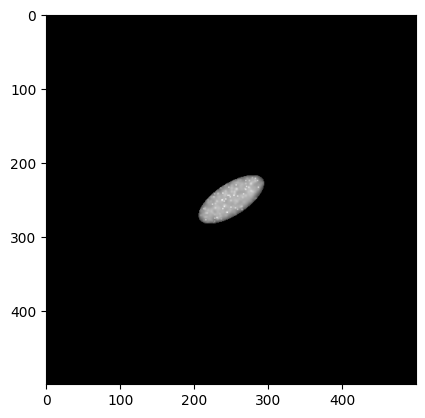

In [9]:
from matplotlib import pyplot as plt
from microscopai_sandbox import MicroscopAIsandbox
from microscopai_sandbox.samples.ellipsoid import Ellipsoid

microscope = MicroscopAIsandbox(fov_size=[500,500])
sample = Ellipsoid(sample_size=microscope.stage_size, bleaching_rate=0.01, n_objects=50, mode="Full")
microscope.set_laser_power(100)
frame = microscope.load_sample(sample, acquire=True)
plt.imshow(frame, vmin=0, cmap="gray")

Stage Moved to position: [2600, 2600]. Acquiring image...


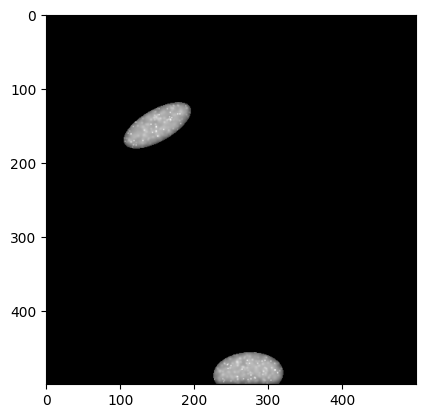

In [10]:
plt.imshow(microscope.move_stage([100, 100], acquire=True), vmin=0, cmap="gray")

In [11]:
import numpy as np

stack = np.zeros((100, 500, 500), dtype=np.float32)

for i in range(100):
    frame = microscope.acquire_image()
    stack[i, :, :] = frame

In [12]:
from tifffile import imwrite

imwrite("stack.tiff", stack)